# 🔬 Customized YOLO with Attention for VIM Polyp Segmental Localization
### VIM Polyp Dataset · Polyp Detection & Localization

**Goal:** Detect and localize polyps in colonoscopy videos using a YOLO backbone augmented with attention modules. The VIM Polyp dataset includes video data, enabling temporal analysis for segmental localization.

**Dataset:** VIM Polyp: A Multimodal Dataset of Colonoscopy Videos, Histopathology Images, and Protein Expression Levels from Colorectal Polyps (Zenodo) — A multimodal dataset focusing on colonoscopy videos with polyp annotations.

> **Reference:** VIM Polyp Dataset: [https://zenodo.org/records/15388073](https://zenodo.org/records/15388073)

**Pipeline Overview:**
1. Environment Setup & Library Imports
2. Dataset Download & Structure (VIM Polyp Videos & Annotations)
3. Data Exploration & Segment Distribution (adapted for video frames)
4. Dataset Preparation for YOLO (video frame extraction, annotation conversion)
5. Custom YOLO Model with CBAM / Coordinate Attention
6. Training with Callbacks & Live Logging
7. Evaluation: mAP, Precision, Recall, Confusion Matrix
8. Attention Map Visualization (Grad-CAM)
9. Results Dashboard

---

## 1. Environment Setup

In [1]:
%pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Install the remaining computer vision & ML dependencies
%pip install -q "ultralytics>=8.3.0" albumentations scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Verify core packages and GPU
import torch
import ultralytics
import albumentations

print(f"✅ PyTorch {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
print(f"✅ torch.version.cuda: {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("❌ GPU NOT detected - this usually means the kernel is still using a CPU-only build or the notebook needs a restart after installation")
    print("   If you just installed PyTorch, restart the kernel and rerun this cell.")

print(f"✅ Ultralytics {ultralytics.__version__}")
print(f"✅ Albumentations {albumentations.__version__}")
print("✅ All packages ready.")

c:\Users\Mohamed.Motear\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ PyTorch 2.6.0+cu118
✅ CUDA available: True
✅ torch.version.cuda: 11.8
✅ GPU: Quadro M2200
✅ GPU Memory: 4.29 GB
✅ Ultralytics 8.4.72
✅ Albumentations 2.0.8
✅ All packages ready.


In [ ]:
import os, sys, shutil, random, json, yaml, math, time, warnings, re
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from ultralytics import YOLO

try:
    import torch
    import ultralytics.nn.tasks as _ultra_tasks
    torch.serialization.add_safe_globals([_ultra_tasks.ClassificationModel])
except Exception:
    # If this fails, loading may still work depending on torch/ultralytics versions.
    pass
import albumentations as A
from albumentations.pytorch import ToTensorV2

try:
    from pytorch_grad_cam import EigenCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    EigenCAM = None
    show_cam_on_image = None
    print("⚠️  pytorch-grad-cam not installed. Run: %pip install pytorch-grad-cam")

warnings.filterwarnings('ignore')

# =========================================================
# GOOGLE / COLAB
# =========================================================
# from google.colab import userdata, auth, drive
# from google import genai

# =========================================================
# HUGGING FACE
# =========================================================
# from huggingface_hub import login
# from datasets import Dataset, load_dataset

# hf_token = userdata.get('HF_TOKEN')
# login(token=hf_token)
# HF_TOKEN = hf_token

# Initialize the official Google GenAI SDK client
# GEMINI_API_KEY = userdata.get('gemini_api_key')
# gemini_client = genai.Client(api_key=GEMINI_API_KEY)

# from google.colab import auth
# auth.authenticate_user()
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Project paths
ROOT        = Path('vim_polyp_yolo') # Changed from 'hyperkvasir_yolo'
DATA_DIR    = ROOT / 'data'
RAW_DIR     = DATA_DIR / 'raw'          # raw VIM Polyp videos & annotations
YOLO_DIR    = DATA_DIR / 'yolo'         # YOLO-formatted dataset
RESULTS     = ROOT / 'results'
MODELS_DIR  = ROOT / 'models'

for d in [RAW_DIR, YOLO_DIR/'images'/'train', YOLO_DIR/'images'/'val',
          YOLO_DIR/'images'/'test', YOLO_DIR/'labels'/'train',
          YOLO_DIR/'labels'/'val', YOLO_DIR/'labels'/'test',
          RESULTS, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Project structure created.")

🖥️  Device: cuda
   GPU: Quadro M2200
   VRAM: 4.3 GB
✅ Project structure created.


## 2. Dataset Download — VIM Polyp


In [5]:
# ─── 3. Segment Extraction & Clean Dataset Prep for Classification ───────────
import os
import shutil
from pathlib import Path
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import GroupShuffleSplit

# Ensure default constants exist
SEED = 42
if 'ROOT' not in locals():
    ROOT = Path('vim_polyp_yolo')

# 1. Configuration & Class Filters
LOCAL_DATA_DIR = r"D:\Marina\colonVideosWithLabels"
CLASSES_TO_DROP = {'anastomosis', 'rectosigmoid', 'colon'}

all_video_files = []
unique_segments = set()

# Scan directory using os.scandir for path safety and performance
if os.path.exists(LOCAL_DATA_DIR):
    for entry in os.scandir(LOCAL_DATA_DIR):
        if entry.is_file():
            filename = entry.name

            # Skip hidden files and macOS metadata leftovers (._ files)
            if filename.startswith(".") or filename.startswith("._"):
                continue

            # Filter specifically for video formats
            if not filename.lower().endswith(('.avi', '.mp4', '.mkv')):
                continue

            stem = os.path.splitext(filename)[0]
            parts = stem.split('-')

            # Extract anatomical segment string from index 5
            if len(parts) > 5:
                segment = parts[5].lower().strip()

                if segment in CLASSES_TO_DROP:
                    continue

                unique_segments.add(segment)
                all_video_files.append((Path(entry.path), segment))

    print(f"✅ Found {len(all_video_files)} valid anatomical localization videos.")
else:
    print(f"❌ Local data directory not found at: {LOCAL_DATA_DIR}")

# 2. Dynamic Class Mapping
CLASS_NAMES = sorted(list(unique_segments))
NUM_CLASSES  = len(CLASS_NAMES)
CLASS_TO_ID  = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f"\nClasses ({NUM_CLASSES}):")
for i, c in enumerate(CLASS_NAMES):
    print(f"   [{i}] {c}")

PALETTE = plt.colormaps['tab10']
CLASS_COLORS = {cls: PALETTE(i % 10)[:3] for i, cls in enumerate(CLASS_NAMES)}

# 3. Artifact Filtering Function
def is_unwanted_frame(frame, brightness_thresh=15, variance_thresh=5):
    """
    Returns True if the frame is pitch black, a solid blue screen,
    or a blank color artifact lacking diagnostic information.
    """
    means, stddevs = cv2.meanStdDev(frame)

    # 1. Pitch-black frames
    if max(means) < brightness_thresh:
        return True

    # 2. Solid/blank screens
    if max(stddevs) < variance_thresh:
        return True

    # 3. Explicit check for digital blue screen artifacts (High Blue, low Green/Red)
    blue_mean = means[0][0]
    green_mean = means[1][0]
    red_mean = means[2][0]
    if blue_mean > 150 and green_mean < 40 and red_mean < 40:
        return True

    return False

# 4. Setup temporary folder for frame extraction before splitting
TEMP_FRAMES_DIR = ROOT / 'data' / 'temp_frames'
TEMP_FRAMES_DIR.mkdir(parents=True, exist_ok=True)

# 5. Extract Valid Frames from Videos
all_pairs = []
skipped_artifacts = 0

if all_video_files:
    for video_path, segment in tqdm(all_video_files, desc="Extracting clean frames for localization"):
        video_id = video_path.stem

        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            continue

        fps = cap.get(cv2.CAP_PROP_FPS) or 30
        frame_interval = max(1, int(fps / 1))  # Extract 1 frame per second of video
        frame_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_count % frame_interval == 0:
                # Filter out unwanted black/blue artifact screens
                if is_unwanted_frame(frame):
                    skipped_artifacts += 1
                    frame_count += 1
                    continue

                frame_name = f"{video_id}_frame_{frame_count:05d}.jpg"
                frame_path = TEMP_FRAMES_DIR / frame_name

                # Save valid frame image
                cv2.imwrite(str(frame_path), frame)
                all_pairs.append((frame_name, segment))

            frame_count += 1
        cap.release()

    print(f"\n✅ Total valid extracted frames: {len(all_pairs)}")
    print(f"🗑️ Skipped {skipped_artifacts} unwanted artifact/blank frames.")
else:
    print("⚠️ No video files to process.")

# 6. Group-Aware Video-Level Split (Prevents Data Leakage)
# ──────────────────────────────────────────────────────────────────────────
splits = {'train': [], 'val': [], 'test': []}

if all_pairs:
    frame_names = [p[0] for p in all_pairs]
    frame_labels = [p[1] for p in all_pairs]
    video_ids = [name.rsplit('_frame_', 1)[0] for name in frame_names]

    df_pairs = pd.DataFrame({
        'frame_name': frame_names,
        'label': frame_labels,
        'video_id': video_ids
    })

    # First Split: Train vs Temp (Val + Test) based on Video ID
    gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    train_idx, temp_idx = next(gss_outer.split(df_pairs, groups=df_pairs['video_id']))

    train_df = df_pairs.iloc[train_idx].reset_index(drop=True)
    temp_df = df_pairs.iloc[temp_idx].reset_index(drop=True)

    # Second Split: Val vs Test based on Video ID
    gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
    val_idx, test_idx = next(gss_inner.split(temp_df, groups=temp_df['video_id']))

    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)

    # Construct split mapping for organizing files
    splits = {
        'train': list(zip(train_df['frame_name'], train_df['label'])),
        'val':   list(zip(val_df['frame_name'], val_df['label'])),
        'test':  list(zip(test_df['frame_name'], test_df['label'])),
    }

    print(f"\n📊 Group-Based Split Summary (by Video ID):")
    print(f"   Train videos: {train_df['video_id'].nunique():<3} | Frames: {len(train_df)}")
    print(f"   Val videos:   {val_df['video_id'].nunique():<3} | Frames: {len(val_df)}")
    print(f"   Test videos:  {test_df['video_id'].nunique():<3} | Frames: {len(test_df)}")

# 7. Organize into YOLO Classification Folder Structure
YOLO_CLASSIFY_DIR = ROOT / 'yolo_classification_data'

if all_pairs:
    for split_name, split_data in splits.items():
        for frame_name, segment_label in tqdm(split_data, desc=f"Organizing {split_name} split"):
            dest_dir = YOLO_CLASSIFY_DIR / split_name / segment_label
            dest_dir.mkdir(parents=True, exist_ok=True)

            src_path = TEMP_FRAMES_DIR / frame_name
            dest_path = dest_dir / frame_name

            if src_path.exists():
                shutil.copy2(str(src_path), str(dest_path))

    # Clean up temp folder now that everything's been copied out
    if TEMP_FRAMES_DIR.exists():
        shutil.rmtree(TEMP_FRAMES_DIR)
    print(f"\n✅ Balanced YOLO classification structure successfully built at: {YOLO_CLASSIFY_DIR.absolute()}")

✅ Found 121 valid anatomical localization videos.

Classes (8):
   [0] ascending
   [1] cecum
   [2] descending
   [3] hepaticflexure
   [4] rectum
   [5] sigmoid
   [6] splenicflexure
   [7] transverse


Extracting clean frames for localization: 100%|██████████| 121/121 [07:49<00:00,  3.88s/it]



✅ Total valid extracted frames: 9419
🗑️ Skipped 1043 unwanted artifact/blank frames.

📊 Group-Based Split Summary (by Video ID):
   Train videos: 84  | Frames: 4868
   Val videos:   18  | Frames: 2333
   Test videos:  19  | Frames: 2218


Organizing test split: 100%|██████████| 2218/2218 [00:03<00:00, 693.38it/s]



✅ Balanced YOLO classification structure successfully built at: d:\Marina\Nebras_RandD\vim_polyp_yolo\yolo_classification_data


## 4. Data Exploration & Visualization

⚠️  No frames extracted or no annotations found to plot distribution.


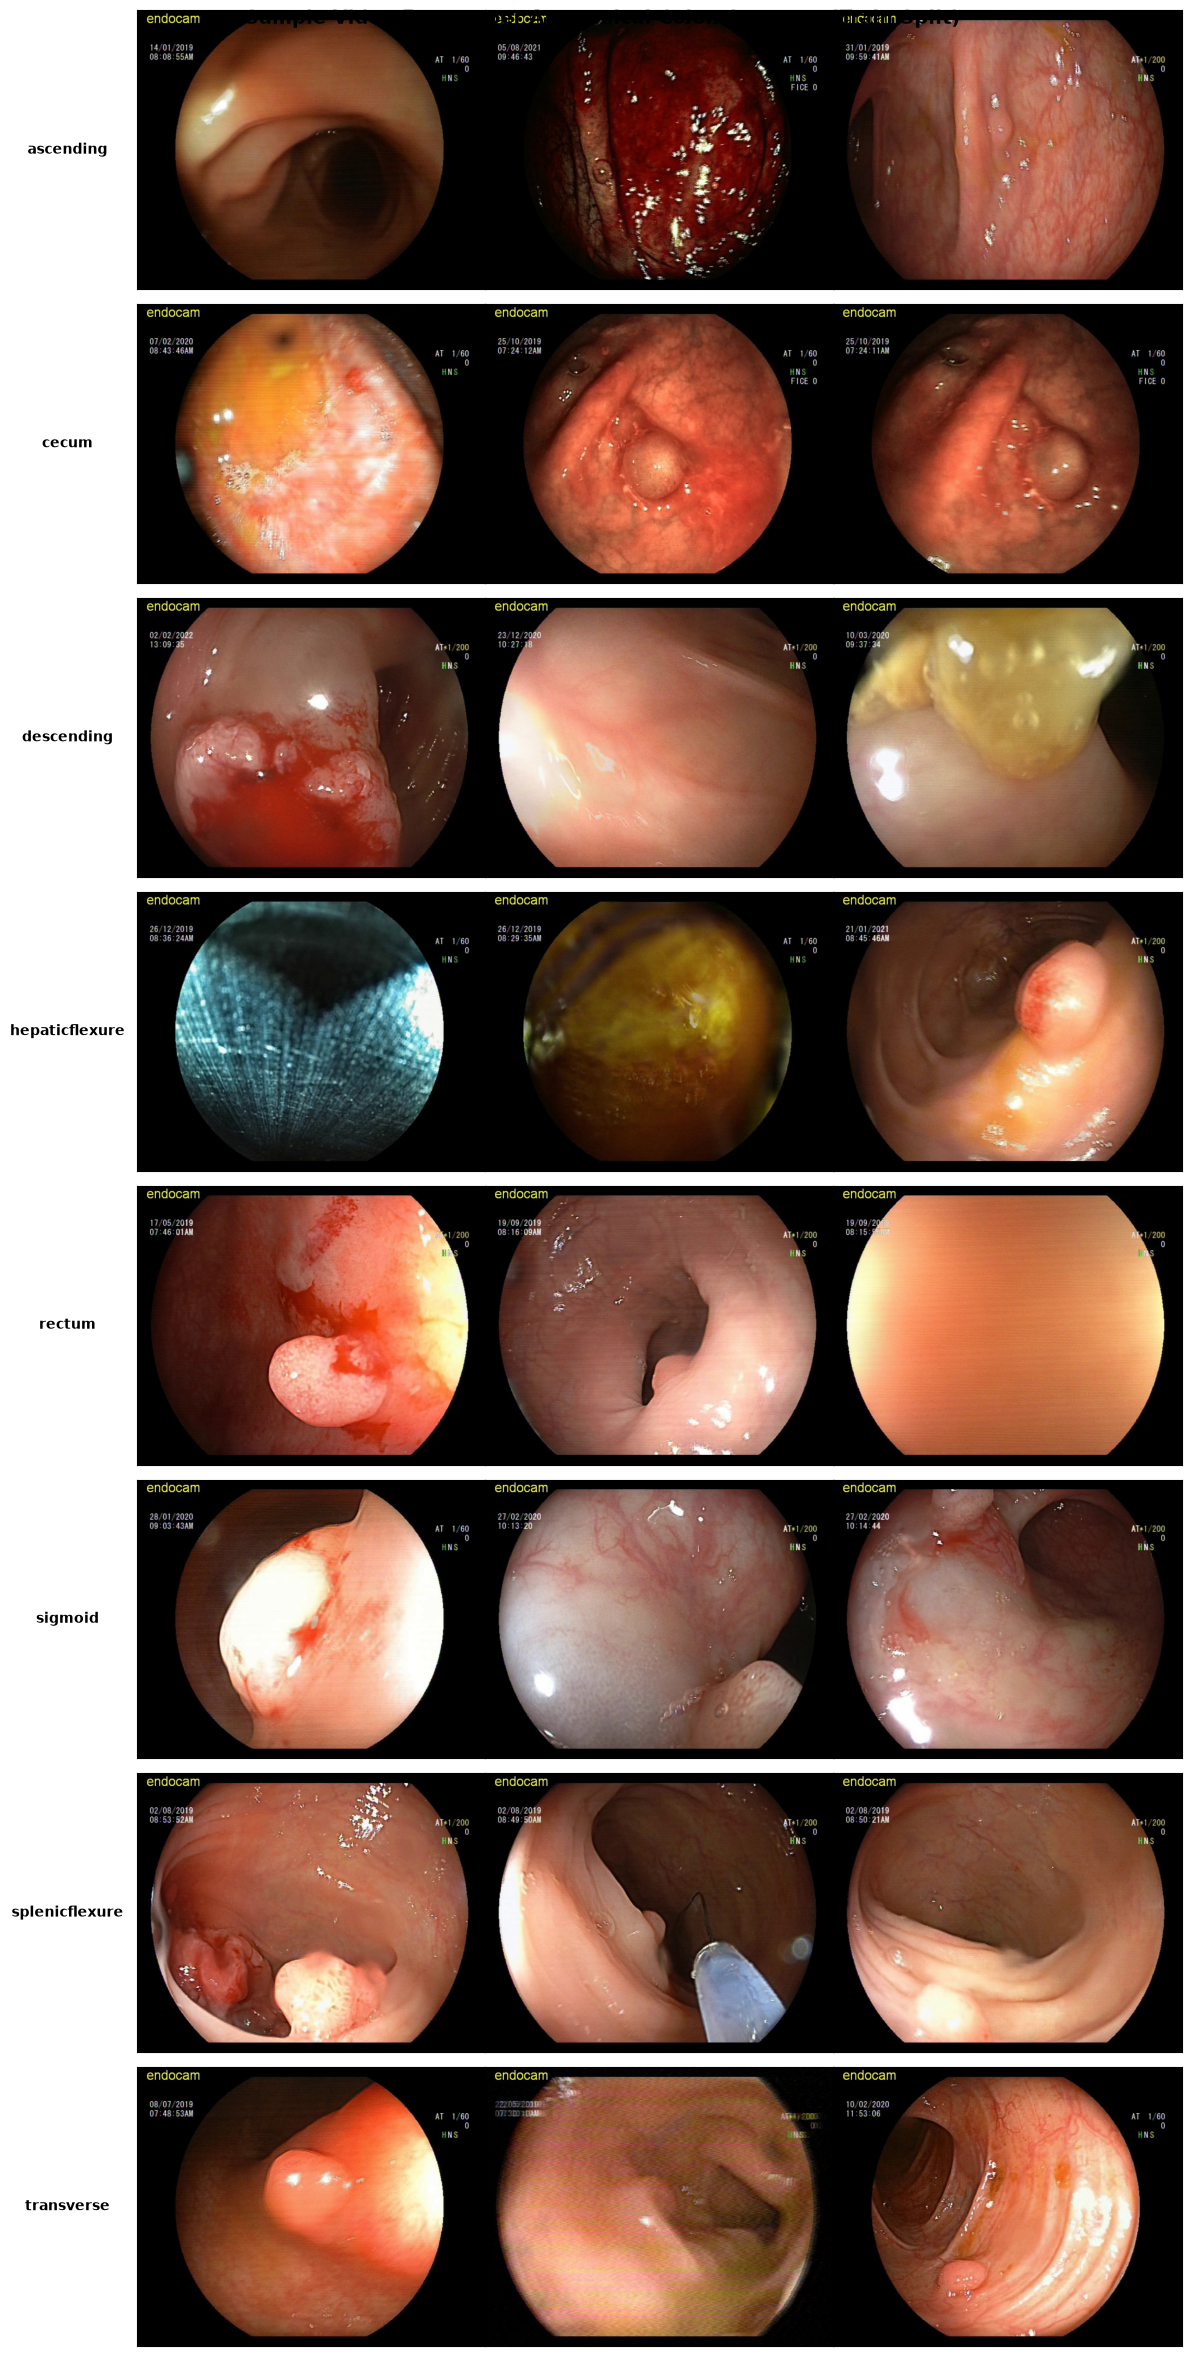

In [ ]:
# ==============================================================================
# ## 4. Data Exploration & Visualization (Classification Mode)
# ==============================================================================
cls_counts = 0
# ─── Segment distribution plot ───────────────────────────────────────────────
if 'cls_counts' in locals() and not cls_counts.empty:
    fig, ax = plt.subplots(figsize=(12, 5))

    # SAFE DESIGN: Generate colors natively from Matplotlib colormap based on the count length
    cmap = plt.colormaps['tab10']
    colors_plot = [cmap(i % 10) for i in range(len(cls_counts))]

    bars = ax.bar(cls_counts.index, cls_counts.values, color=colors_plot, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, cls_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f"{val:,}", ha='center', va='bottom', fontsize=9)

    ax.set_title('Frame Distribution across Colon Segments', fontweight='bold', fontsize=13)
    ax.set_xlabel('Anatomical Segment')
    ax.set_ylabel('Frame Count')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(RESULTS / 'segment_distribution.png', dpi=150)
    plt.show()
else:
    print("⚠️  No frames extracted or no annotations found to plot distribution.")

# ─── Sample frame grid for anatomical segments ────────────────────────────────
def show_sample_grid_classify(yolo_classification_dir, class_names, n_samples=3):
    """Show sample frames directly from the organized split folders."""
    train_dir = yolo_classification_dir / 'train'

    # Identify which classes actually have folders and images inside train split
    active_classes = []
    by_class_paths = {}

    for cid, c_name in enumerate(class_names):
        class_folder = train_dir / c_name
        if class_folder.exists():
            images = list(class_folder.glob('*.jpg'))
            if images:
                active_classes.append((cid, c_name))
                by_class_paths[cid] = images

    rows_to_plot = len(active_classes)
    if rows_to_plot == 0:
        print("⚠️  No sorted classification frames found to display samples.")
        return

    fig, axes = plt.subplots(rows_to_plot, n_samples, figsize=(n_samples * 4, rows_to_plot * 3))
    axes = np.atleast_2d(axes) # Safeguard mapping dimensions for varying classes

    for row_idx, (cid, c_name) in enumerate(active_classes):
        paths = by_class_paths[cid]
        sample = random.sample(paths, min(n_samples, len(paths)))

        for col in range(n_samples):
            ax = axes[row_idx, col]
            if col < len(sample):
                img = cv2.cvtColor(cv2.imread(str(sample[col])), cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                if col == 0:
                    ax.set_ylabel(c_name, fontsize=10, rotation=0,
                                  labelpad=50, va='center', fontweight='bold')
            else:
                ax.set_visible(False)
            ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle('Sample Video Frames per Anatomical Colon Segment (Train Split)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'segment_samples.png', dpi=120, bbox_inches='tight')
    plt.show()

if 'YOLO_CLASSIFY_DIR' in locals() and YOLO_CLASSIFY_DIR.exists():
    show_sample_grid_classify(YOLO_CLASSIFY_DIR, CLASS_NAMES, n_samples=3)
else:
    print("⚠️  Classification directory layout not detected. Check extraction cell.")

## 5. Dataset Preparation — Convert to YOLO Format


In [7]:
# ─── 5. Dataset Mappings & Verification for Classification ───────────────────
# Update project data directory to point to your clean classification folders
YOLO_DIR = (ROOT / 'yolo_classification_data').resolve()

# Verify directory exists
if YOLO_DIR.exists():
    print(f"✅ Active Dataset Path: {YOLO_DIR}\n")

    # Define dataset configuration for later dashboard tracking cells
    classify_cfg = {
        'path': str(YOLO_DIR),
        'train': 'train',
        'val': 'val',
        'test': 'test',
        'nc': NUM_CLASSES,
        'names': CLASS_NAMES,
    }

    # Save a reference classification yaml if required, though YOLO reads directories directly
    YAML_PATH = YOLO_DIR / 'dataset_classification.yaml'
    with open(YAML_PATH, 'w') as f:
        yaml.dump(classify_cfg, f, default_flow_style=False)

    print(f"✅ Classification config snapshot cached at {YAML_PATH}")
    print(yaml.dump(classify_cfg, default_flow_style=False))
else:
    print(f"⚠️  Classification folder structure not found at {YOLO_DIR}. Please run the extraction cell first.")

✅ Active Dataset Path: D:\Marina\Nebras_RandD\vim_polyp_yolo\yolo_classification_data

✅ Classification config snapshot cached at D:\Marina\Nebras_RandD\vim_polyp_yolo\yolo_classification_data\dataset_classification.yaml
names:
- ascending
- cecum
- descending
- hepaticflexure
- rectum
- sigmoid
- splenicflexure
- transverse
nc: 8
path: D:\Marina\Nebras_RandD\vim_polyp_yolo\yolo_classification_data
test: test
train: train
val: val



## 6. Attention Modules — CBAM & Coordinate Attention

These modules are inserted into the YOLO neck to help the model focus on discriminative mucosal texture and vascular patterns that distinguish colon segments.

In [8]:
# ==============================================================================
# ## 6. Attention Modules — CBAM & Coordinate Attention
# ==============================================================================
class ChannelAttention(nn.Module):
    """Squeeze-and-Excite style channel attention."""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(1, in_channels // reduction)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, in_channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        a = self.fc(self.avg_pool(x))
        m = self.fc(self.max_pool(x))
        return self.sigmoid(a + m) * x


class SpatialAttention(nn.Module):
    """Spatial attention via max+avg pooling across channel dim."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.max(dim=1, keepdim=True)[0]
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1))) * x


class CBAM(nn.Module):
    """Full CBAM block: channel → spatial."""
    def __init__(self, in_channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.ca = ChannelAttention(in_channels, reduction)
        self.sa = SpatialAttention(spatial_kernel)

    def forward(self, x):
        return self.sa(self.ca(x))


class CoordinateAttention(nn.Module):
    """Coordinate Attention — encodes X and Y position separately."""
    def __init__(self, in_channels, out_channels, reduction=32):
        super().__init__()
        mid = max(8, in_channels // reduction)
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))
        self.conv1  = nn.Conv2d(in_channels, mid, 1, bias=False)
        self.bn1    = nn.BatchNorm2d(mid)
        self.act    = nn.Hardswish(inplace=True)
        self.conv_h = nn.Conv2d(mid, out_channels, 1, bias=False)
        self.conv_w = nn.Conv2d(mid, out_channels, 1, bias=False)

    def forward(self, x):
        n, c, h, w = x.shape
        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)
        y   = torch.cat([x_h, x_w], dim=2)
        y   = self.act(self.bn1(self.conv1(y)))
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)
        return x * torch.sigmoid(self.conv_h(x_h)) * torch.sigmoid(self.conv_w(x_w))


# ─── Sanity check ─────────────────────────────────────────────────────────────
dummy = torch.randn(2, 256, 32, 32)
print(f"✅ CBAM output            : {CBAM(256)(dummy).shape}")
print(f"✅ CoordAttention output  : {CoordinateAttention(256, 256)(dummy).shape}")




✅ CBAM output            : torch.Size([2, 256, 32, 32])
✅ CoordAttention output  : torch.Size([2, 256, 32, 32])


## 7. Custom YOLO Model — Injecting Attention into YOLOv8 Neck

In [ ]:
# ==============================================================================
# ## 7. Custom YOLO Model — Injecting Attention into YOLOv8-cls Neck
# ==============================================================================
import inspect
import torch
import torch.nn as nn
from ultralytics.models.yolo.classify import ClassificationTrainer

class AttentionYOLOClassification(nn.Module):
    """
    Wraps an Ultralytics YOLO Classification model and inserts attention
    modules before the final classification head layer.
    """
    def __init__(self, yolo_model, attention_type='cbam'):
        super().__init__()
        self.yolo = yolo_model.model if hasattr(yolo_model, 'model') else yolo_model
        neck_channels = self._detect_neck_channels()
        print(f"🔍 Detected classification neck channels: {neck_channels}")

        self.attn_modules = nn.ModuleList()
        for ch in neck_channels:
            if attention_type == 'cbam':
                self.attn_modules.append(CBAM(ch))
            else:
                self.attn_modules.append(CoordinateAttention(ch, ch))

        self._neck_channels = neck_channels
        self.attention_type = attention_type
        self._register_hooks()

        # Retain Ultralytics attributes required by trainer/validator
        self.yaml = getattr(self.yolo, 'yaml', {})
        self.names = getattr(self.yolo, 'names', None)
        self.nc = getattr(self.yolo, 'nc', None)
        self.task = 'classify'

        _base_stride = getattr(self.yolo, 'stride', None)
        if _base_stride is not None:
            self.stride = _base_stride

    def _detect_neck_channels(self):
        feats = []
        def _hook(module, inp, out):
            if isinstance(inp[0], torch.Tensor) and inp[0].dim() == 4:
                feats.append(inp[0].shape[1])

        classify_layer = next(
            (m for m in self.yolo.modules() if m.__class__.__name__ == 'Classify'), None
        )
        hooks = [classify_layer.register_forward_hook(_hook)] if classify_layer else []
        
        # SAFEGUARD FIX: Match dummy input tensor to model's active device (CPU or CUDA)
        device = next(self.yolo.parameters()).device
        with torch.no_grad():
            try:
                self.yolo(torch.zeros(1, 3, 224, 224, device=device))
            except Exception:
                pass

        for h in hooks:
            h.remove()
        return feats if feats else [512]

    def _register_hooks(self):
        self._hooks = []
        target_layers = [m for m in self.yolo.modules() if m.__class__.__name__ in ('C2f', 'SPPF')]
        for i, layer in enumerate(target_layers[-1:]):
            def make_hook(attn_idx):
                def hook_fn(module, inp, out):
                    if attn_idx < len(self.attn_modules) and isinstance(out, torch.Tensor):
                        try:
                            return self.attn_modules[attn_idx](out)
                        except Exception:
                            return out
                    return out
                return hook_fn
            self._hooks.append(layer.register_forward_hook(make_hook(i)))

    def forward(self, x, *args, **kwargs):
        return self.yolo(x, *args, **kwargs)

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()

print("✅ AttentionYOLO for Classification defined.")


# ==============================================================================
# Custom Trainer
# ==============================================================================
class AttentionClassificationTrainer(ClassificationTrainer):
    """
    Overrides get_model() so the attention wrapper survives into training.
    """
    def __init__(self, overrides=None, attention_type='cbam', _callbacks=None):
        self.attention_type = attention_type
        super().__init__(overrides=overrides, _callbacks=_callbacks)

    def get_model(self, cfg=None, weights=None, verbose=True):
        base_model = super().get_model(cfg=cfg, weights=weights, verbose=verbose)
        base_params = sum(p.numel() for p in base_model.parameters())

        wrapped = AttentionYOLOClassification(base_model, attention_type=self.attention_type)
        wrapped_params = sum(p.numel() for p in wrapped.parameters())

        print(f"📐 Base model params:    {base_params:,}")
        print(f"📐 Wrapped model params: {wrapped_params:,}  "
              f"(+{wrapped_params - base_params:,} from {self.attention_type} attention)")

        if wrapped_params == base_params:
            print("⚠️ WARNING: Parameter count did not change — attention module "
                  "may not actually be attached. Check _register_hooks().")

        return wrapped

print("✅ AttentionClassificationTrainer defined.")

# ─── Version guard ────────────────────────────────────────────────────────────
_expected_params = {'self', 'cfg', 'weights', 'verbose'}
_actual_params = set(inspect.signature(ClassificationTrainer.get_model).parameters)
if not _expected_params.issubset(_actual_params):
    raise RuntimeError(
        f"Ultralytics' ClassificationTrainer.get_model() signature has changed "
        f"(expected params {_expected_params}, found {_actual_params}). "
        f"Update AttentionClassificationTrainer.get_model() to match before training."
    )
print(f"✅ ClassificationTrainer.get_model() signature OK: {inspect.signature(ClassificationTrainer.get_model)}")

✅ AttentionYOLO for Classification defined.
✅ AttentionClassificationTrainer defined.
✅ ClassificationTrainer.get_model() signature OK: (self, cfg=None, weights=None, verbose: 'bool' = True)


## 8. Training

In [ ]:
# ─── Training Configuration ───────────────────────────────────────────────────
import ultralytics.nn.tasks as _ultra_tasks

DATASET_PATH = str((ROOT / 'yolo_classification_data').resolve())

TRAIN_CFG = dict(
    data         = DATASET_PATH,
    epochs       = 100,
    imgsz        = 224,
    batch        = 16,
    device       = DEVICE,
    project      = str(RESULTS),
    optimizer    = 'AdamW',
    lr0          = 1e-3,
    lrf          = 0.01,
    warmup_epochs = 3,
    cos_lr       = True,
    fliplr       = 0.5,
    verbose      = True,
)

# SAFEGUARD FIX: For classification, YOLO reads classes from directory structure automatically.
# Remove 'classes' to prevent parameter conflict in classification training mode.
TRAIN_CFG.pop('classes', None)
if 'NUM_CLASSES' in locals():
    TRAIN_CFG['name'] = 'vim_polyp_cls'

# Safe globals for PyTorch secure unpickling
SAFE_GLOBALS = [
    _ultra_tasks.ClassificationModel,
    torch.nn.modules.container.Sequential,
    torch.nn.modules.conv.Conv2d,
    torch.nn.modules.activation.SiLU,
    torch.nn.modules.batchnorm.BatchNorm2d,
]

print('✅ Training config ready. Run experiment cells below.')

✅ Training config ready. Run experiment cells below.


In [11]:
# ─── Experiment 1: Baseline YOLOv8n (no attention) ───────────────────────────
print("=" * 60)
print("EXPERIMENT 1 — Baseline YOLOv8n (VIM Polyp)")
print("=" * 60)

from ultralytics.nn.tasks import DetectionModel

with torch.serialization.safe_globals([DetectionModel]):
    model = YOLO("yolov8n-cls.pt")
results_baseline = model.train(
    **{**TRAIN_CFG, 'name': 'exp1_baseline'}
)
print("\n✅ Baseline training complete.")

EXPERIMENT 1 — Baseline YOLOv8n (VIM Polyp)
New https://pypi.org/project/ultralytics/8.4.103 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.72  Python-3.12.10 torch-2.6.0+cu118 CUDA:0 (Quadro M2200, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=[0, 1, 2, 3, 4, 5, 6, 7], close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\Marina\Nebras_RandD\vim_polyp_yolo\yolo_classification_data, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=3

# Validation

# KVASIR NORMAL CECUM

In [2]:
import os
from pathlib import Path
from ultralytics import YOLO

# 1. Define paths
WEIGHTS_PATH = r"D:\Marina\Nebras_RandD\runs\classify\vim_polyp_yolo\results\exp1_baseline\weights\best.pt"
DATASET_PATH = r"D:\Marina\kvasir\kvasir-dataset-v2\normal-cecum"

# 2. Check if weights file exists
if not os.path.exists(WEIGHTS_PATH):
    raise FileNotFoundError(
        f"Weights file not found at: {WEIGHTS_PATH}\n"
        "Please update `WEIGHTS_PATH` to point to your saved best.pt location."
    )

# 3. Load classification model
model = YOLO(WEIGHTS_PATH)

# 4. Run Prediction
print("\n--- Starting Model Prediction ---")
results = model.predict(
    source=DATASET_PATH,
    imgsz=640,
    conf=0.25,
    save=True,
    project=r"D:\Marina\Nebras_RandD\runs\classify\kvasir_evaluation",
    name="exp1_normal_cecum_preds",
)

# 5. Output Summary
print("\n--- Prediction Results Summary ---")
print(f"Total images processed: {len(results)}\n")

# Display the top prediction for the first 10 images
for i, result in enumerate(results[:10]):
    top_class_id = result.probs.top1  # Class index with highest probability
    top_class_name = result.names[top_class_id]  # Predicted label
    confidence = result.probs.top1conf.item()  # Confidence score

    print(
        f"Image {i+1:2d}: {Path(result.path).name} -> {top_class_name} ({confidence * 100:.2f}%)"
    )


--- Starting Model Prediction ---

image 1/1000 D:\Marina\kvasir\kvasir-dataset-v2\normal-cecum\00b1b20b-ce2b-449c-93fc-6df854e3ab33.jpg: 640x640 ascending 0.45, rectum 0.38, descending 0.10, hepaticflexure 0.06, sigmoid 0.00, 9.7ms
image 2/1000 D:\Marina\kvasir\kvasir-dataset-v2\normal-cecum\00b99f19-2c31-4c7c-931a-4c3b38d70d1a.jpg: 640x640 ascending 0.81, rectum 0.15, descending 0.04, hepaticflexure 0.00, cecum 0.00, 9.4ms
image 3/1000 D:\Marina\kvasir\kvasir-dataset-v2\normal-cecum\00f3d2cc-93ea-40f0-9b88-b159b07a49cb.jpg: 640x640 ascending 0.69, rectum 0.15, descending 0.14, transverse 0.01, sigmoid 0.01, 9.2ms
image 4/1000 D:\Marina\kvasir\kvasir-dataset-v2\normal-cecum\0111fb06-3113-4abf-9050-7bfb8d4688f5.jpg: 640x640 ascending 0.91, descending 0.09, rectum 0.00, sigmoid 0.00, transverse 0.00, 10.1ms
image 5/1000 D:\Marina\kvasir\kvasir-dataset-v2\normal-cecum\0163b3a2-9aa1-4b23-a9a8-aff07a738f16.jpg: 640x640 ascending 0.52, rectum 0.25, descending 0.23, transverse 0.00, sigmoid

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

# 1. Define the true class label for all images in this folder
TRUE_LABEL = "cecum"

# 2. Extract predicted class names for all 1000 images
predictions = []
for result in results:
    top_class_id = result.probs.top1
    predicted_class_name = result.names[top_class_id]
    predictions.append(predicted_class_name)

# 3. Get all unique classes present in the model's vocabulary
all_classes = list(results[0].names.values())

# Ensure TRUE_LABEL is included in class list even if 0 predictions were made for it
if TRUE_LABEL not in all_classes:
    all_classes.append(TRUE_LABEL)

# Sort classes so 'cecum' or alphabetical order is clean
all_classes = sorted(all_classes)

# 4. Count frequency of each predicted class
pred_counts = Counter(predictions)

print("=" * 50)
print(f"PREDICTION BREAKDOWN FOR {len(results)} 'NORMAL-CECUM' IMAGES")
print("=" * 50)
for cls_name in all_classes:
    count = pred_counts.get(cls_name, 0)
    pct = (count / len(results)) * 100
    print(f"Predicted as '{cls_name}': {count:4d} / {len(results)} ({pct:.2f}%)")

correct_cecum = pred_counts.get(TRUE_LABEL, 0)
accuracy = (correct_cecum / len(results)) * 100
print("-" * 50)
print(
    f"Accuracy on Cecum folder: {accuracy:.2f}% ({correct_cecum}/{len(results)} correct)"
)
print("=" * 50)

# 5. Build and Plot Confusion Matrix
# Row = True Class ('cecum'), Columns = Predicted Classes
cm_row = [pred_counts.get(cls, 0) for cls in all_classes]

plt.figure(figsize=(10, 3))
sns.heatmap(
    [cm_row],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=all_classes,
    yticklabels=[TRUE_LABEL],
    cbar=True,
)

plt.title(
    f"Confusion Matrix: Performance on Normal-Cecum Dataset (N={len(results)})"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# C3VD CECUM

In [ ]:
from collections import Counter
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# 1. Define paths
WEIGHTS_PATH = r"D:\Marina\Nebras_RandD\runs\classify\vim_polyp_yolo\results\exp1_baseline\weights\best.pt"  # Or your pairwise model path
C3VD_FOLDER = r"D:\Marina\C3VD\cecum_t1_a"

# 2. Check path & filter for files ending with '_color.png'
color_images = glob.glob(os.path.join(C3VD_FOLDER, "*_color.png"))

if not os.path.exists(WEIGHTS_PATH):
    raise FileNotFoundError(f"Weights file not found at: {WEIGHTS_PATH}")

if len(color_images) == 0:
    # If images are inside a nested subfolder (e.g., cecum_t1_a/color/ or cecum_t1_a/rgb/)
    color_images = glob.glob(
        os.path.join(C3VD_FOLDER, "**", "*_color.png"), recursive=True
    )

print(
    f"Found {len(color_images)} color images ending with '_color.png' in {C3VD_FOLDER}"
)

if len(color_images) == 0:
    raise FileNotFoundError(
        "No files ending with '_color.png' were found. Please check your folder structure."
    )

# 3. Load model
model = YOLO(WEIGHTS_PATH)

# 4. Run Inference (matching training resolution imgsz=224)
print("\n--- Running Prediction on C3VD Color Images ---")
results = model.predict(
    source=color_images,  # Pass the explicit list of color image paths
    imgsz=224,  # Use 224x224 matching training resolution
    conf=0.25,
    save=True,
    project=r"D:\Marina\Nebras_RandD\runs\classify\c3vd_evaluation",
    name="cecum_t1_a_color_preds",
)

# 5. Extract Predictions
predictions = []
for result in results:
    top_class_id = result.probs.top1
    predicted_class_name = result.names[top_class_id]
    predictions.append(predicted_class_name)

# 6. Prediction Breakdown Analysis
total_images = len(results)
pred_counts = Counter(predictions)
all_classes = sorted(list(model.names.values()))

print("\n" + "=" * 50)
print(f"PREDICTION BREAKDOWN FOR C3VD CECUM_T1_A ({total_images} IMAGES)")
print("=" * 50)

for cls_name in all_classes:
    count = pred_counts.get(cls_name, 0)
    pct = (count / total_images) * 100
    print(f"Predicted as '{cls_name}': {count:4d} / {total_images} ({pct:.2f}%)")

# Determine accuracy assuming true anatomical region is 'cecum'
cecum_key = next(
    (cls for cls in all_classes if "cecum" in cls.lower()), "cecum"
)
correct_cecum = pred_counts.get(cecum_key, 0)
accuracy = (correct_cecum / total_images) * 100

print("-" * 50)
print(
    f"Accuracy on C3VD Cecum folder: {accuracy:.2f}% ({correct_cecum}/{total_images} correct)"
)
print("=" * 50)

# 7. Plot Prediction Distribution
cm_row = [pred_counts.get(cls, 0) for cls in all_classes]

plt.figure(figsize=(8, 3))
sns.heatmap(
    [cm_row],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=all_classes,
    yticklabels=["True: cecum"],
    cbar=True,
)

plt.title(f"Model Predictions on C3VD cecum_t1_a Color Images (N={total_images})")
plt.xlabel("Predicted Class")
plt.ylabel("Ground Truth")
plt.tight_layout()
plt.show()